In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from utils import plot_tsne
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 128
batch_size = 128
num_epochs_ae = 5
num_epochs_cls = 5
learning_rate = 1e-3
# Early stopping parameters
patience = 3
best_val_loss = float('inf')
patience_counter = 0
checkpoint_dir = 'checkpoints'
patience_classifier = 3
best_val_loss_classifier = float('inf')
patience_counter_classifier = 0
os.makedirs(checkpoint_dir, exist_ok=True)

# Configuration
config = {
    'MNIST': {
        'input_channels': 1,
        'input_size': 28,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'mean': (0.1307,),
        'std': (0.3081,)
    },
    'CIFAR10': {
        'input_channels': 3,
        'input_size': 32,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        'mean': (0.5, 0.5, 0.5),
        'std': (0.5, 0.5, 0.5)
    }
}

In [2]:

# class Autoencoder(nn.Module): # Gal
#     def __init__(self, input_channels, input_size):
#         super().__init__()
#         self.input_dim = input_channels * input_size ** 2
#         self.input_channels = input_channels
#         self.input_size = input_size
#         self.encoder = nn.Sequential(
#             nn.Linear(self.input_dim, 512),
#             nn.ReLU(),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Linear(256, latent_dim)
#         )
#         self.decoder = nn.Sequential(
#             nn.Linear(latent_dim, 256),
#             nn.ReLU(),
#             nn.Linear(256, 512),
#             nn.ReLU(),
#             nn.Linear(512, self.input_dim)
#         )

#     def forward(self, x):
#         x = x.view(-1, self.input_dim)
#         x = self.encoder(x)
#         x = self.decoder(x)
#         return x.view(-1, self.input_channels, self.input_size, self.input_size)   



In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_channels, input_size):
        super(Autoencoder, self).__init__()
        # Store input parameters
        self.input_size = input_size
        self.input_channels = input_channels
        self.input_dim = input_channels * input_size ** 2
        
        # Calculate feature size after two stride-2 convolutions
        self.feature_size = input_size // 4
        # Calculate flattened size after convolutions
        self.flattened_size = 32 * self.feature_size * self.feature_size
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(self.flattened_size, latent_dim),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, self.flattened_size),
            nn.ReLU(),
            nn.Unflatten(1, (32, self.feature_size, self.feature_size)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, input_channels, 4, stride=2, padding=1),
            nn.Tanh()  # Output range [-1, 1] to match normalized input
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon
        
    def encode(self, x):
        """Get the latent code from the encoder"""
        return self.encoder(x)

In [4]:

# class Classifier(nn.Module): # Gal
#     def __init__(self, encoder, input_dim, num_classes):
#         super().__init__()
#         self.encoder = encoder
#         self.input_dim = input_dim
#         self.fc1 = nn.Linear(latent_dim, 256)
#         self.fc2 = nn.Linear(256, num_classes)

#     def forward(self, x):
#         x = x.view(-1, self.input_dim)
#         x = self.encoder(x)
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

In [5]:
class Classifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super(Classifier, self).__init__()
        self.encoder = encoder  # Use the pre-trained encoder from the autoencoder
        
        # Get the latent dimension from the encoder's last layer
        # Assuming the last layer of the encoder is a Linear layer followed by ReLU
        latent_dim = list(encoder.children())[-2].out_features
        
        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        # Extract features using the encoder
        features = self.encoder(x)
        # Pass through fully connected layers
        x = F.relu(self.fc1(features))
        output = self.fc2(x)
        return output

In [6]:
def load_dataset(dataset_name):
    cfg = config[dataset_name]
    if dataset_name == 'MNIST':
        train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=cfg['transform'])
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=cfg['transform'])
    elif dataset_name == 'CIFAR10':
        train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cfg['transform'])
        test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cfg['transform'])
    
    # Split train into train and validation
    train_size = len(train_dataset) - 10000
    train_dataset, val_dataset = random_split(train_dataset, [train_size, 10000])
    
    return train_dataset, val_dataset, test_dataset

def create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size):
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )



In [7]:
def train_autoencoder(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_loss = float('inf')
    patience_counter = 0
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, _ in tqdm(train_loader, desc=f"AE Epoch {epoch+1}"):
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

        val_loss = evaluate(model, val_loader, device, criterion)
        print(f'AE Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}')

        # Early stopping and checkpoint logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/ae_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
        
        
        if isinstance(model, Autoencoder):
            with torch.no_grad():
                dataiter = iter(val_loader)
                images, _ = next(dataiter)
                images = images.to(device)
                outputs = model(images)
                images = images.cpu()
                outputs = outputs.cpu()
                
                # Get image dimensions automatically
                batch_size, channels, height, width = images.shape
                random_indices = torch.randperm(batch_size)[:5]

                # Denormalize images using the config values
                def denormalize(x, dataset_name):
                    mean = torch.tensor(config[dataset_name]['mean']).view(channels, 1, 1)
                    std = torch.tensor(config[dataset_name]['std']).view(channels, 1, 1)
                    return x * std + mean
                
                images_display = denormalize(images, dataset_name)
                outputs_display = denormalize(outputs, dataset_name)
                
                fig, axes = plt.subplots(2, 5, figsize=(12, 4))
                for i in range(5):
                    idx = random_indices[i]
                    if channels == 1:
                        axes[0, i].imshow(images_display[idx].squeeze(), cmap='gray')
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].squeeze(), cmap='gray')
                        axes[1, i].axis('off')
                    else:
                        axes[0, i].imshow(images_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[1, i].axis('off')
                
                axes[0, 0].set_title('Original', size=14)
                axes[1, 0].set_title('Reconstructed', size=14)
                plt.tight_layout()
                plt.show()
    return model

def train_classifier(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_acc = 0
    patience_counter = 0
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"CLS Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        val_acc = evaluate_classifier(model, val_loader, device)
        print(f'CLS Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Val Acc: {val_acc:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/cls_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    return model

def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, images).item()
    return total_loss / len(loader)

def evaluate_classifier(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total


In [7]:
dataset_name = "MNIST"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


Training Autoencoder on MNIST


AE Epoch 1: 100%|██████████| 391/391 [00:09<00:00, 40.06it/s]


AE Epoch [1/5] Train Loss: 0.4447, Val Loss: 0.3617


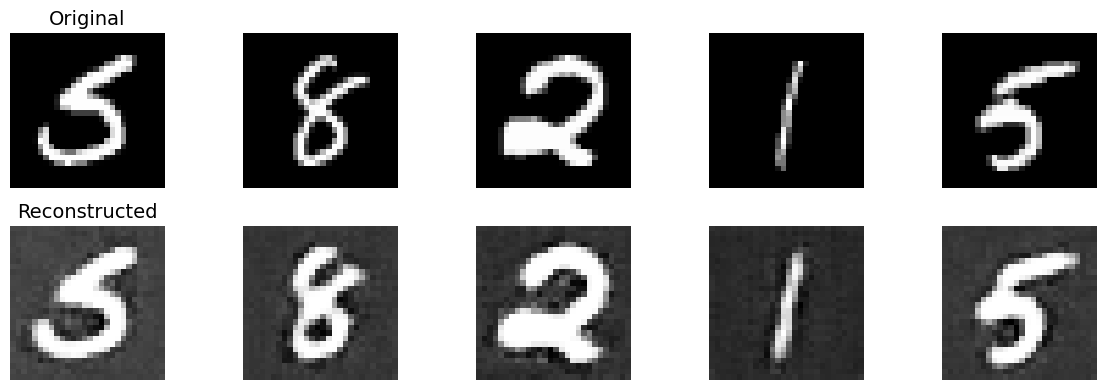

AE Epoch 2: 100%|██████████| 391/391 [00:09<00:00, 39.73it/s]


AE Epoch [2/5] Train Loss: 0.3512, Val Loss: 0.3450


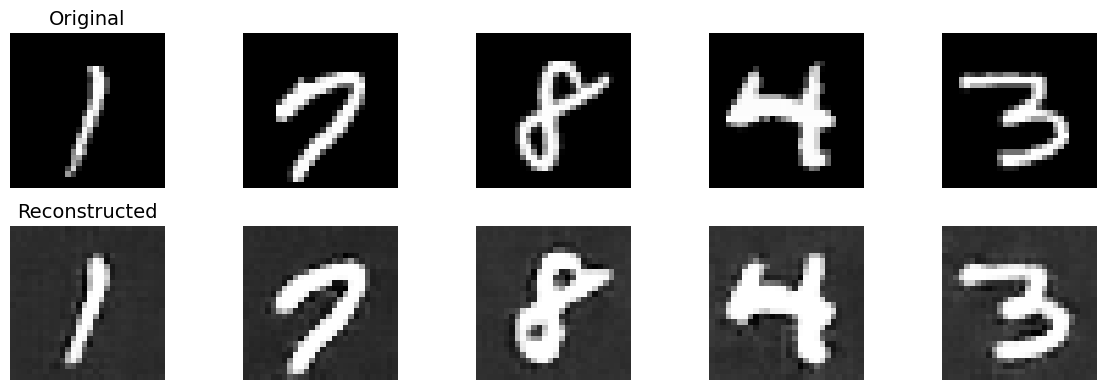

AE Epoch 3: 100%|██████████| 391/391 [00:09<00:00, 40.70it/s]


AE Epoch [3/5] Train Loss: 0.3407, Val Loss: 0.3380


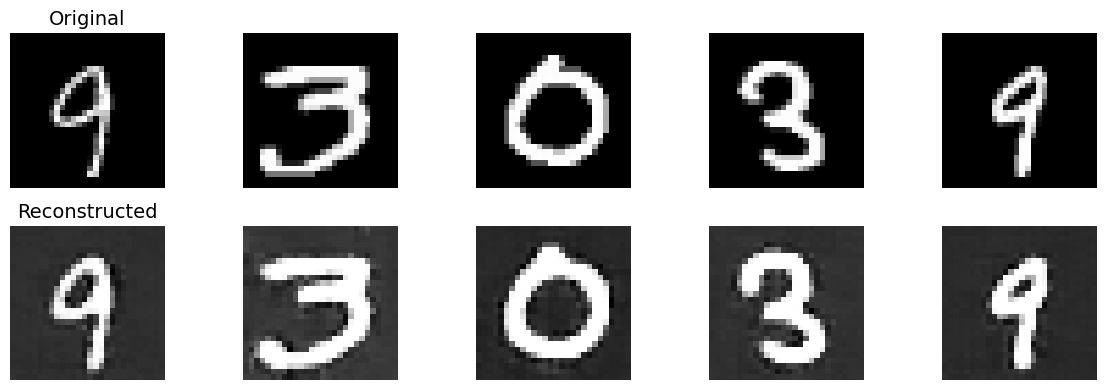

AE Epoch 4: 100%|██████████| 391/391 [00:09<00:00, 40.37it/s]


AE Epoch [4/5] Train Loss: 0.3352, Val Loss: 0.3339


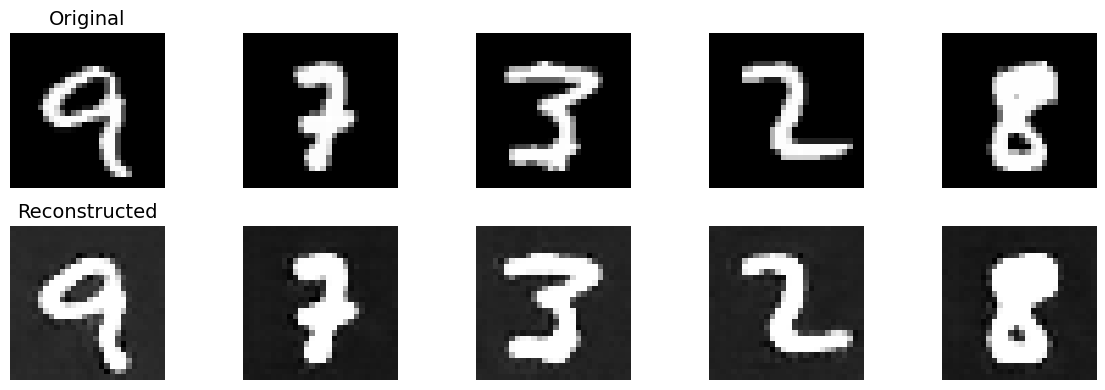

AE Epoch 5: 100%|██████████| 391/391 [00:10<00:00, 38.05it/s]


AE Epoch [5/5] Train Loss: 0.3319, Val Loss: 0.3321


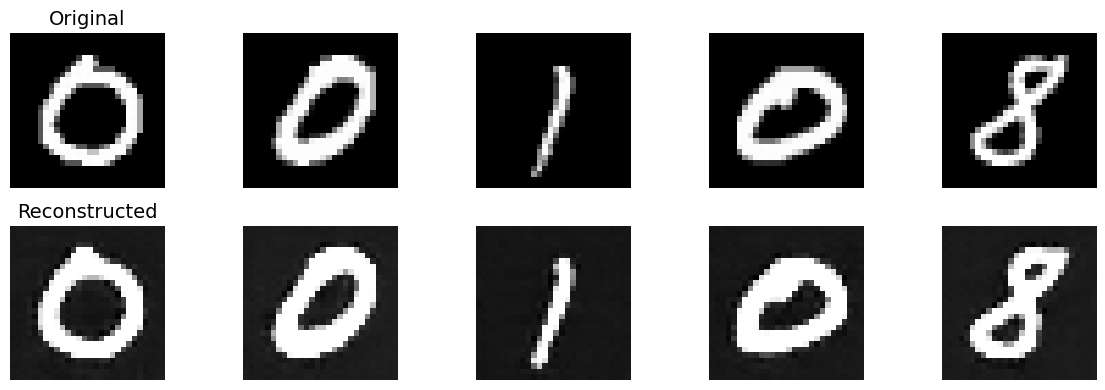

In [8]:
ae = Autoencoder(cfg['input_channels'], cfg['input_size']).to(device)
print(f"Training Autoencoder on {dataset_name}")
ae = train_autoencoder(ae, train_loader, val_loader, device, num_epochs_ae, dataset_name)





In [9]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.3390


In [29]:
# Classifier

# classifier = Classifier(ae.encoder, ae.input_dim, cfg['num_classes']).to(device)
classifier = Classifier(ae.encoder, config[dataset_name]['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, num_epochs_cls, dataset_name)


Training Classifier on CIFAR10


CLS Epoch 1: 100%|██████████| 313/313 [00:08<00:00, 36.75it/s]


CLS Epoch [1/5] Train Loss: 1.9530, Val Acc: 36.12%


CLS Epoch 2: 100%|██████████| 313/313 [00:08<00:00, 36.67it/s]


CLS Epoch [2/5] Train Loss: 1.7926, Val Acc: 38.01%


...

CLS Epoch [3/5] Train Loss: 1.7220, Val Acc: 39.86%


CLS Epoch 4: 100%|██████████| 313/313 [00:08<00:00, 35.75it/s]


CLS Epoch [4/5] Train Loss: 1.6704, Val Acc: 41.26%


CLS Epoch 5:  43%|████▎     | 136/313 [00:03<00:04, 36.05it/s]


KeyboardInterrupt: 

In [19]:

# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')




Final Test Accuracy on MNIST: 91.43%


In [11]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne


In [12]:

# Visualization
plot_tsne(ae.encoder, test_loader, device)


In [ ]:
####################################

In [8]:
# now for CIFAR10
dataset_name = "CIFAR10"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


In [9]:
ae = Autoencoder(cfg['input_channels'], cfg['input_size']).to(device)
print(f"Training Autoencoder on {dataset_name}")
ae = train_autoencoder(ae, train_loader, val_loader, device, num_epochs_ae, dataset_name)


Training Autoencoder on CIFAR10


AE Epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x4096 and 2048x128)

In [22]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.0326


In [27]:
# Classifier

# classifier = Classifier(ae.encoder, ae.input_dim, cfg['num_classes']).to(device)
classifier = Classifier(ae.encoder, config[dataset_name]['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, num_epochs_cls, dataset_name)


Training Classifier on CIFAR10


CLS Epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [3072, 128]

In [25]:

# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')



Final Test Accuracy on CIFAR10: 36.42%


In [18]:
# Visualization
plot_tsne(ae.encoder, test_loader, device)

In [ ]:
###############################################